In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Titanic-Dataset[1].csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df. shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Copy of dataset
for keeping raw data untouched. if something goes wrong, we can always go back to the original.


In [ ]:
df_clean = df.copy()
df_clean.duplicated().sum()  # checked and remove if any. prevent duplicate records from affecting analysis.

np.int64(0)

In [ ]:
df_clean.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Which should we use: Mean or Median?
Use the mean if the data is fairly symmetric.
Use the median if the data is skewed or has outliers.

We'll confirm this with a histogram.

In [ ]:
df_clean['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


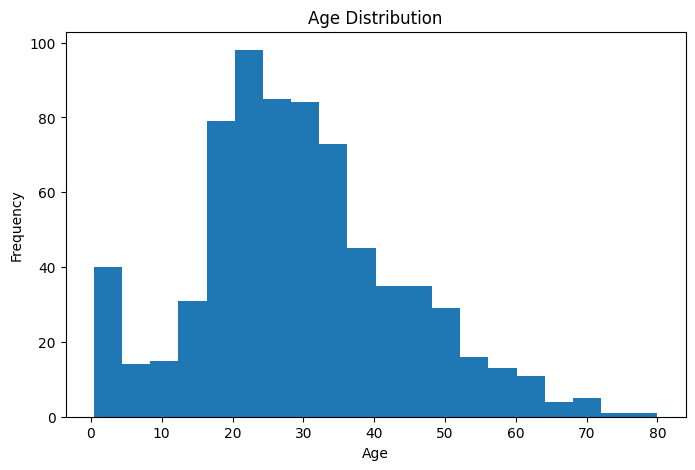

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean['Age'].dropna(),bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


the median is generally preferred because age contains some outliers and isn't perfectly symmetric.

In [ ]:
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())  # filled missing values with median. median is robust to outliers.

In [ ]:
df_clean['Age'].isnull().sum()

np.int64(0)

In [ ]:
df_clean['Embarked'].mode()

,Embarked
0,S


In [ ]:
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])  # filled missing values with mode . most frequent category is appropriate for a small number of missing values.

df_clean['Embarked'].isnull().sum()

np.int64(0)

In [ ]:
df_clean['Cabin'].isnull().sum()

np.int64(687)

Why not fill them?

Because about 77% of the Cabin values are missing. Filling them with the mean, median, or mode doesn't make sense for this type of data and could introduce misleading information.

We'll drop the column:

In [ ]:
df_clean.drop('Cabin', axis=1, inplace=True) # dropped column. more than 75% of values were missing.

In [ ]:
df_clean.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [ ]:
df_clean.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Save and download the Cleaned Dataset

In [ ]:
df_clean.to_csv('Cleaned_titanic.csv', index=False)

from google.colab import files
files.download('Cleaned_titanic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exploratory Data Analysis (EDA)
Objective
- What was the overall survival rate?
- Did women survive more often than men?
- Did first-class passengers have a higher survival rate?
- How did age affect survival?
- Did fare influence survival?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Cleaned_titanic.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


# Overall survival rate

In [ ]:
survival_rate = df['Survived'].mean()*100

print(f'Overall Survival Rate: {survival_rate:2f}%')

Overall Survival Rate: 38.383838%


only around 38% of passenger survived, indicating that the majority of passenger did not survive the disaster.

# Survival by Gender

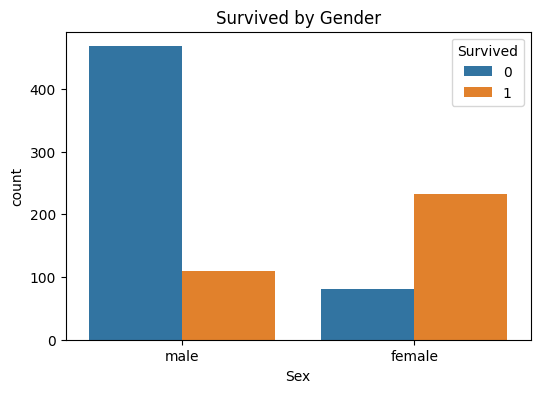

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survived by Gender')
plt.savefig('survival_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()


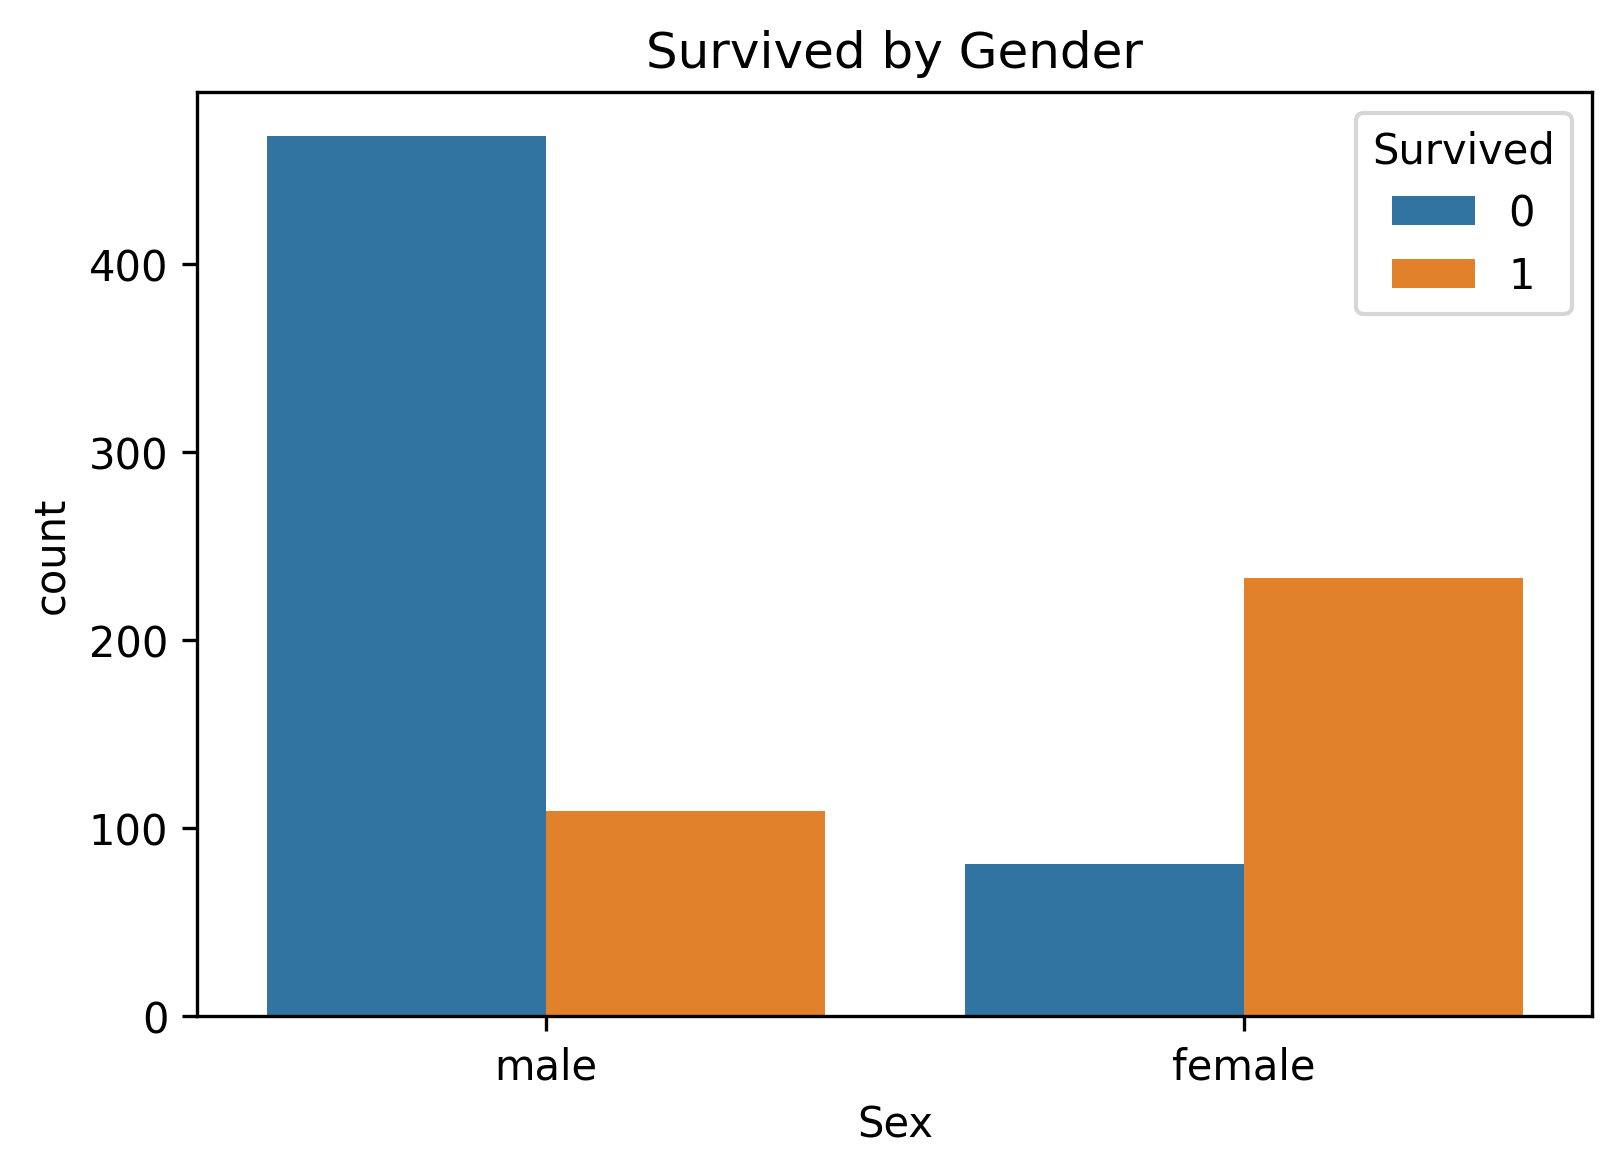

In [ ]:
from IPython.display import Image, display

display(Image("survival_by_gender.png"))

In [ ]:
from google.colab import files
files.download('survival_by_gender.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Female passenger had a substantially higher survival rate than male passenger.

# Survival by Passenger Class

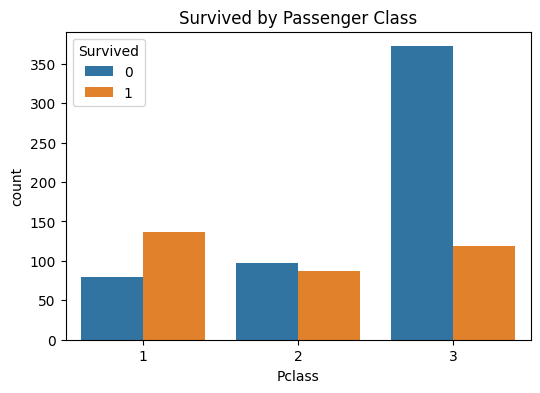

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survived by Passenger Class")

plt.savefig('survival_by_passenger_class.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('survival_by_passenger_class.png')

first-class passenger had the highest survival rate, while third-class passenger had the lowest.

# Age Distribution

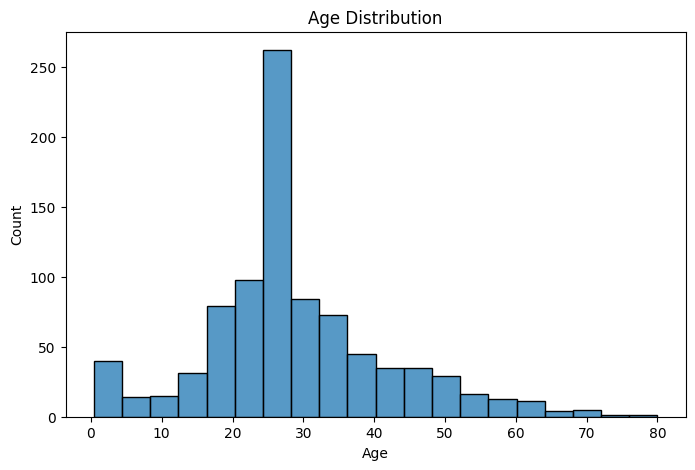

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)
plt.title('Age Distribution')

plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('age_distribution.png')

Most passengers were between 20 and 40 years old, indicating that young adults formed the largest passenger group. The age distribution is slightly right-skewed, with relatively few elderly passengers. This suggests that age may be an important factor to investigate when analyzing survival patterns.

# Fare Dsitribution

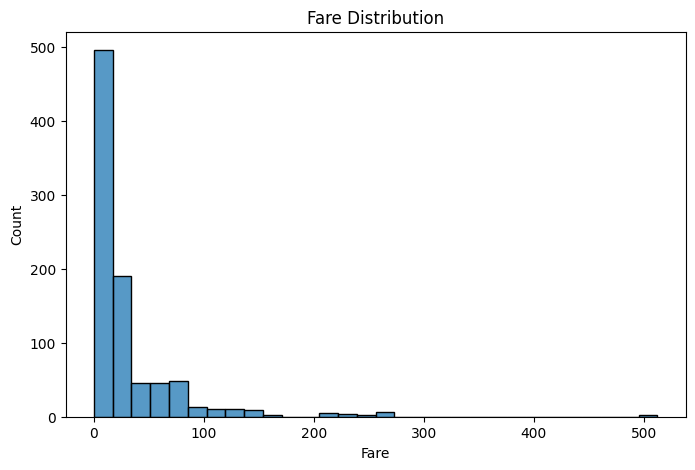

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30)

plt.title('Fare Distribution')

plt.savefig('fare_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('fare_distribution.png')

First-class passengers paid significantly higher fares than second- and third-class passengers, highlighting a clear difference in ticket pricing across travel classes. This relationship suggests that passenger class and fare are closely connected and may both influence survival.

# Correlation Heatmap


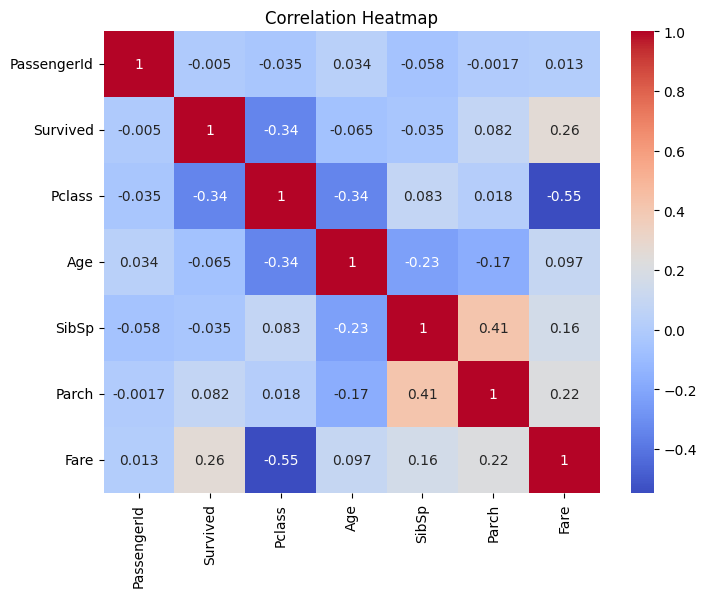

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap( numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('correlation_heatmap.png')


# Boxplot of fare by passenger class

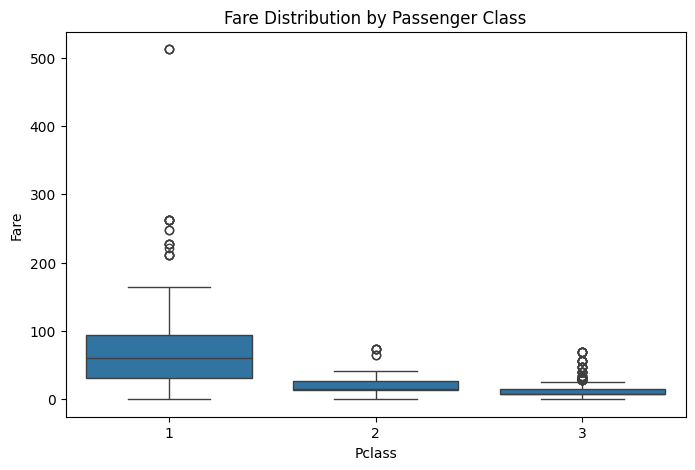

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Pclass', y='Fare', data=df)

plt.title('Fare Distribution by Passenger Class')

plt.savefig('fare_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('fare_boxplot.png')



# Create FamilySize

SibSp = Number of siblings/spouses
Parch = Number of parents/children

Instead of analyzing these separately, combine them.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Cleaned_titanic.csv")

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


# Create IsAlone
If FamilySize == 1 - Passenger was alone


Otherwise

↓

Passenger was with family.



In [ ]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['FamilySize','IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


# Extract Passenger Title

In [ ]:
df['Title'] = df['Name'].str.extract(r",\s*([^|.]+)\.")

df[['Name', 'Title']].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [ ]:
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Lady', 'Sir', 'Don', 'Jonkheer', 'Capt', 'the Countess', 'Mme', 'Mlle','Ms']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27


# Create Age Groups

In [ ]:
bins = [0, 12, 19, 35, 60, 100]

labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


# Create Fare Groups

In [ ]:
df['FareGroup'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

df[['Fare', 'FareGroup']].head()

,Fare,FareGroup
0,7.2500,Low
1,71.2833,Premium
2,7.9250,Medium
3,53.1000,Premium
4,8.0500,Medium


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr,Young Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs,Adult,Premium
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss,Young Adult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs,Young Adult,Premium
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr,Young Adult,Medium


In [ ]:
df.to_csv('featured_titanic.csv', index=False)

from google.colab import files

files.download('featured_titanic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>